# 06 - Semi-Synthetic Causal Policy Evaluation

Known potential outcomes audit naive, IPTW, matching, g-computation and cross-fitted AIPW. This is not a causal claim from the ULB data.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
ART = ROOT / 'artifacts'
FIG = ROOT / 'reports' / 'figures'
pd.set_option('display.max_columns', 100)


In [2]:
pd.read_csv(ART / 'causal_estimates.csv')

Out[0]: 
  estimand          estimator   estimate
0      ATE              truth  11.871105
1      ATE              naive  11.901075
2      ATE               IPTW  11.817804
3      ATE      g-computation  11.799117
4      ATE  cross-fitted AIPW  11.543703
5      ATT              truth  11.605096
6      ATT        PS matching  11.640621


In [3]:
pd.read_csv(ART / 'causal_balance.csv')

Out[0]: 
      feature  smd_before  smd_after_iptw  smd_after_matching
0  risk_score    0.081911        0.020599            0.026455
1  log_amount    0.554586        0.003950           -0.003376
2    hour_sin   -0.205255       -0.017467            0.009004
3    hour_cos   -0.198685       -0.014896           -0.002384


In [4]:
json.loads((ART / 'causal_diagnostics.json').read_text())

Out[0]: 
{'semi_synthetic': True,
 'treatment_rate': 0.23770472542707427,
 'true_ate': 11.871104636135065,
 'true_att': 11.60509588770265,
 'aipw_ate': 11.543703063231474,
 'aipw_influence_function_95pct_ci': [11.260510229271494, 11.826895897191454],
 'aipw_full_refit_bootstrap_95pct_ci': {'low': 9.658289418832755,
  'median': 11.458018657910657,
  'high': 11.848430294565283,
  'repetitions': 30},
 'iptw_effective_sample_size': 39853.708640950674,
 'unclipped_propensity_min': 0.06187142666742912,
 'unclipped_propensity_max': 0.952967243353379,
 'matching_treated_retained': 10114,
 'matching_treated_total': 10116,
 'scope': 'Estimator audit with constructed potential outcomes, not an identified effect from the public dataset.'}


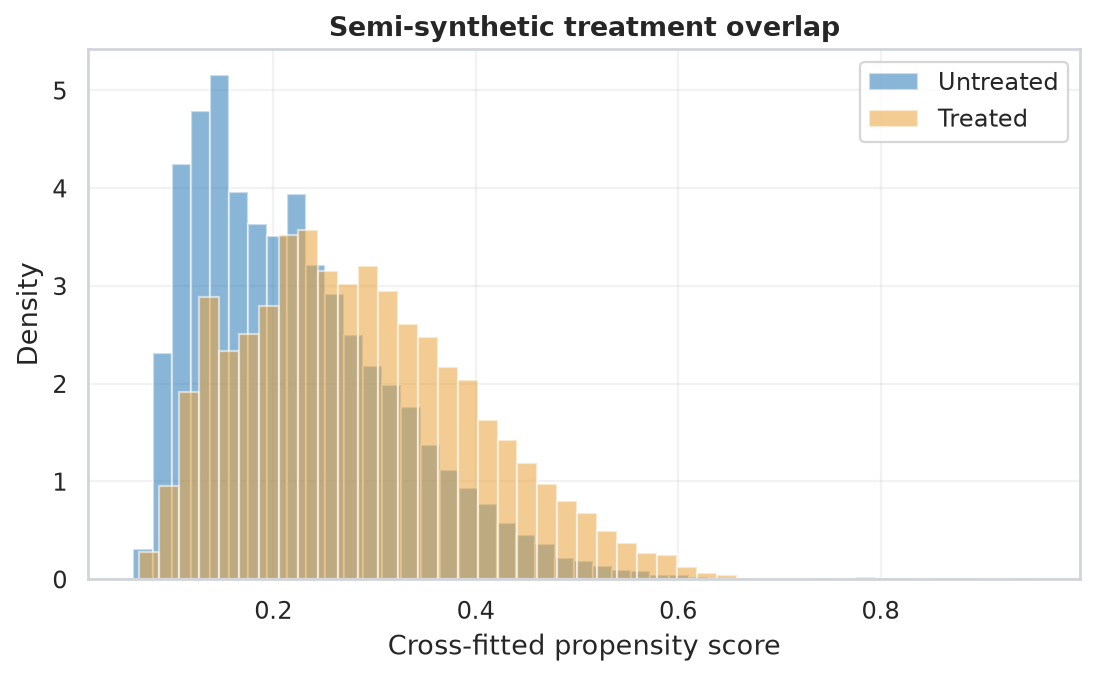

In [5]:
display(Image(filename=str(FIG / '08_causal_overlap.png')))

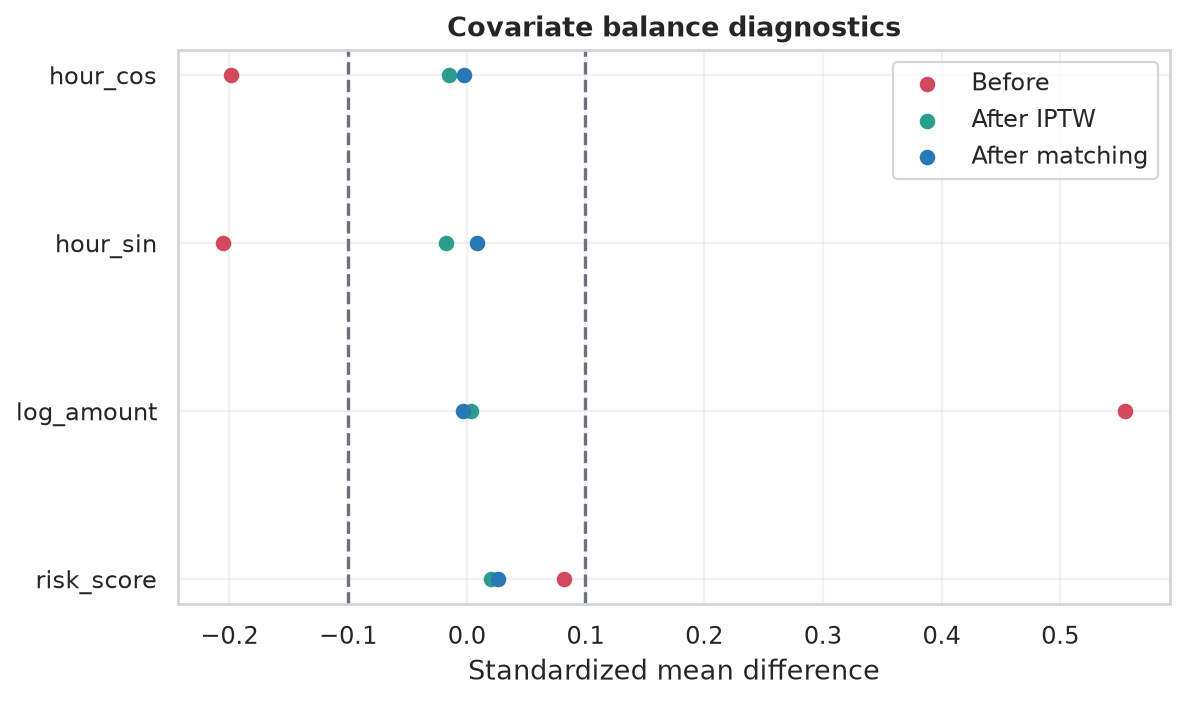

In [6]:
display(Image(filename=str(FIG / '09_causal_balance.png')))